In [ ]:
import sys
from telfit import Modeler

import numpy as np
import os 
import matplotlib.pyplot as plt
from scipy.stats import qmc
import h5py


/home/mvasist/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/mvasist/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/home/mvasist/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


## Test

In [ ]:
# Set the start and end wavelength, in nm
wavestart = 500.0
waveend = 1800.0

# Make the model
modeler = Modeler(nmolecules=12)
model = modeler.MakeModel(humidity=50.0,
                          lowfreq=1e7/waveend,
                          highfreq=1e7/wavestart, 
                          )


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
18.41user 2.18system 0:21.35elapsed 96%CPU (0avgtext+0avgdata 7552maxresident)k
88616inputs+2071160outputs (24major+1089minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
8.71user 1.90system 0:11.07elapsed 95%CPU (0avgtext+0avgdata 7680maxresident)k
3840inputs+1512000outputs (0major+1105minor)pagefaults 0swaps



Running exec: lblrtm




...

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
1.88user 1.31system 0:03.23elapsed 98%CPU (0avgtext+0avgdata 7680maxresident)k
240inputs+775600outputs (0major+1100minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
1.72user 1.24system 0:03.00elapsed 98%CPU (0avgtext+0avgdata 7680maxresident)k
0inputs+708136outputs (0major+1091minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
0.64user 0.92system 0:01.59elapsed 98%CPU (0avgtext+0avgdata 7680maxresident)k
0inputs+151256outputs (0major+1084minor)pagefaults 0swaps


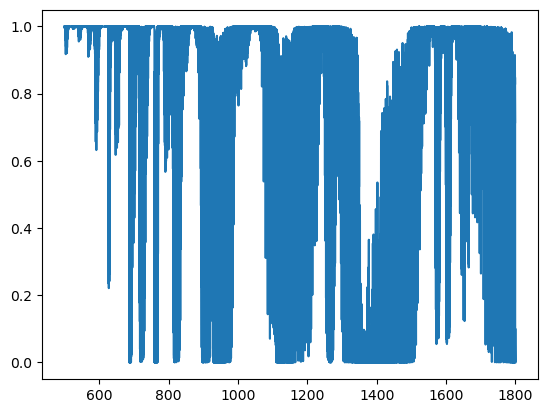

In [3]:
plt.plot(model.x, model.y)
plt.show()


## Using all model parameters

In [ ]:

# Wavelength range in nm
wavestart = 500.0   # nm
waveend = 1800.0    # nm

modeler = Modeler(nmolecules=12)

model = modeler.MakeModel(
    # Atmospheric conditions at telescope
    pressure=795.0,         # hPa
    temperature=283.0,      # Kelvin
    humidity=50.0,          # percent relative humidity
    angle=45.0,             # zenith distance (degrees); airmass = sec(angle)

    # Spectral range (wavenumber, cm^-1)
    lowfreq=1e7 / waveend,  # cm^-1  (from nm)
    highfreq=1e7 / wavestart,  # cm^-1  (from nm)

    # Molecular mixing ratios (ppmv)
    co2=368.5,
    o3=0.039,
    n2o=0.32,
    co=0.14,
    ch4=1.8,
    o2=210000.0,
    no=1.1e-19,
    so2=0.0001,
    no2=0.0001,
    nh3=0.0001,
    hno3=0.00056,

    # Observatory location
    lat=30.6,               # degrees
    alt=2.1,                # km above sea level

    # Optional output processing
    wavegrid=None,          # 1D np array to resample onto (or None)
    resolution=None,        # R = lam/dlam for Gaussian convolution (or None)
    save=False,             # save the generated model to disk
    libfile=None,           # filename to log saved model path (if save=True)
    vac2air=True,           # convert vacuum -> air wavelengths
)

# model.x = wavelength (nm), model.y = fractional transmission
print(f'Wavelength range: {model.x.min():.1f} - {model.x.max():.1f} nm')
print(f'Number of points: {len(model.x)}')


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
21.77user 2.90system 0:25.86elapsed 95%CPU (0avgtext+0avgdata 6912maxresident)k
91544inputs+2071328outputs (29major+1092minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
10.06user 2.22system 0:12.48elapsed 98%CPU (0avgtext+0avgdata 7680maxresident)k
4744inputs+1512080outputs (0major+1105minor)pagefaults 0swaps



Running exec: lblrtm




...


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
2.03user 1.64system 0:03.73elapsed 98%CPU (0avgtext+0avgdata 6912maxresident)k
1544inputs+708152outputs (14major+1087minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
0.75user 1.15system 0:01.92elapsed 99%CPU (0avgtext+0avgdata 6912maxresident)k
0inputs+151272outputs (0major+1081minor)pagefaults 0swaps


Wavelength range: 499.9 - 1799.5 nm
Number of points: 5869040


In [4]:
plt.figure(figsize=(12, 4))
plt.plot(model.x, model.y, lw=0.5)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Telluric model (full parameter set)')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## Generate a training set


In [ ]:
os.environ["TELLURICMODELING"] = os.environ["HOME"]+ "/Documents/Tellurics/TelFit/telluric_templates/"


In [ ]:

n_samples = 10  

# Parameter ranges: [low, high]
param_ranges = {
    'pressure':    (750, 850),         # hPa
    'temperature': (270, 300),         # Kelvin
    'angle':       (0, 60),            # zenith distance (degrees)
    'humidity':    (10, 90),           # percent
    'co2':         (350, 450),         # ppmv
    'o3':          (0.02, 0.08),       # ppmv
    'n2o':         (0.30, 0.35),       # ppmv
    'co':          (0.05, 0.30),       # ppmv
    'ch4':         (1.7, 2.1),         # ppmv
    'o2':          (209000, 210000),   # ppmv
    'no':          (1e-5, 1e-3),       # ppmv
    'so2':         (1e-5, 1e-3),       # ppmv
    'no2':         (1e-5, 1e-3),       # ppmv
    'nh3':         (1e-5, 1e-3),       # ppmv
    'hno3':        (1e-4, 1e-3),       # ppmv
}

# Fixed parameters
fixed_params = {
    'lat': 30.6,
    'alt': 2.1,
}

param_names = list(param_ranges.keys())
bounds_low = [v[0] for v in param_ranges.values()]
bounds_high = [v[1] for v in param_ranges.values()]

# Latin Hypercube Sampling
sampler = qmc.LatinHypercube(d=len(param_names), seed=42)
samples_unit = sampler.random(n=n_samples)  # values in [0, 1]
samples = qmc.scale(samples_unit, bounds_low, bounds_high)  # scaled to real ranges

print(f'Generated {n_samples} LHS samples across {len(param_names)} parameters')
print(f'Parameter names: {param_names}')
print(f'Sample shape: {samples.shape}')  # (n_samples, 15)


In [ ]:
# Wavelength range: 0.5 - 1.8 um
wavestart = 500.0   # nm
waveend = 1800.0    # nm

# Load wavelength grid from stellar spectra HDF5
stellar_h5 = Path('/home/mvasist/Documents/Tellurics/Phoenix/phoenix_training_set.h5')

with h5py.File(stellar_h5, 'r') as hf:
    stellar_wavegrid = hf['wavelengths'][0]  # (D,) — take first row since all are the same
    print(f'Stellar wavelength grid: {stellar_wavegrid.shape}')
    print(f'Range: {stellar_wavegrid.min():.4f} - {stellar_wavegrid.max():.4f} um')


modeler = Modeler(nmolecules=12)

transmission_list = []
labels_list = []
wavelength = None

for idx in range(n_samples):
    params = dict(zip(param_names, samples[idx]))
    
    if idx % 100 == 0:
        print(f'Generating model {idx+1}/{n_samples}')
    
    try:
        model = modeler.MakeModel(
            lowfreq=1e7 / waveend,
            highfreq=1e7 / wavestart,
            wavegrid=stellar_wavegrid * 1000,  # um -> nm
            **params,
            **fixed_params,
        )
        
        if wavelength is None:
            wavelength = torch.tensor(model.x / 1000, dtype=torch.float32)
        
        transmission_list.append(torch.tensor(model.y, dtype=torch.float32))
        labels_list.append(torch.tensor(samples[idx], dtype=torch.float32))
        
    except Exception as e:
        print(f'  FAILED at {idx}: {e}')
        continue

print(f'\nSuccessfully generated {len(transmission_list)} models')


# Output path
outdir = Path('/home/mvasist/Documents/Tellurics/TelFit/telluric_templates')
outdir.mkdir(exist_ok=True)
h5_path = outdir / 'telluric_templates.h5'

In [ ]:
# Stack and save to HDF5
transmission = torch.stack(transmission_list)  # (N, D)
labels = torch.stack(labels_list)              # (N, n_params)

print(f'Transmission shape: {transmission.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Wavelength shape: {wavelength.shape}')

with h5py.File(h5_path, 'w') as hf:
    hf.create_dataset('wavelength', data=wavelength.numpy())         # (D,) — shared grid
    hf.create_dataset('transmission', data=transmission.numpy())     # (N, D)
    hf.create_dataset('labels', data=labels.numpy())                 # (N, n_params)
    hf['labels'].attrs['columns'] = param_names
    # Store fixed params as attributes for reproducibility
    for k, v in fixed_params.items():
        hf.attrs[f'fixed_{k}'] = v
    hf.attrs['wavestart_nm'] = wavestart
    hf.attrs['waveend_nm'] = waveend

print(f'\nSaved to {h5_path}')


In [ ]:
# Verify
import matplotlib.pyplot as plt

with h5py.File(h5_path, 'r') as hf:
    print('Datasets:', list(hf.keys()))
    print(f'  wavelength:   {hf["wavelength"].shape}')
    print(f'  transmission: {hf["transmission"].shape}')
    print(f'  labels:       {hf["labels"].shape}')
    print(f'  label columns: {list(hf["labels"].attrs["columns"])}')

    wl = hf['wavelength'][:]
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    for i in np.random.choice(len(hf['transmission']), 5, replace=False):
        lbl = hf['labels'][i]
        ax.plot(wl, hf['transmission'][i], lw=0.5,
                label=f'H={lbl[3]:.0f}% T={lbl[1]:.0f}K P={lbl[0]:.0f}hPa z={lbl[2]:.0f}°')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Transmission')
    ax.legend(fontsize='small')
    ax.set_title('Sample telluric models from grid')
    plt.tight_layout()
    plt.show()
